In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)

df = pd.read_csv('Churn_Modelling.csv')
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Perform train-test-split
from sklearn.model_selection import train_test_split

target = df.loc[:, 'Exited']
features = df.drop('Exited', axis=1)

features_train, features_test, target_train, target_test = train_test_split(features,
                                                                            target,
                                                                            random_state=42,
                                                                            test_size=0.1)

In [ ]:
def clean_data(df):
    """Returns cleaned DataFrame.

    Processes:
        -removing irrelevant columns
        -transform data into less demanding formats

    Args:
        df (pd.DataFrame) : uncleaned DataFrame

    Returns:
        df  (pd.DataFrame) : cleaned DataFrame

    """

    import warnings
    warnings.simplefilter(action='ignore', category=FutureWarning)

    # removing unnecessary columns
    df = df.drop(['RowNumber', 'Surname', 'CustomerId'], axis=1)

    # convert 'object' to 'category' type
    category_columns = ['Geography']
    for column in category_columns:
        df[column] = df[column].astype('category')

    # convert 'object' to numerical columns
    df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})

    # convert numerical columns: data type optimization
    df['Gender'] = df['Gender'].astype('uint8')
    df['HasCrCard'] = df['HasCrCard'].astype('uint8')
    df['IsActiveMember'] = df['IsActiveMember'].astype('uint8')
    df['Age'] = df['Age'].astype('uint8')
    df['Tenure'] = df['Tenure'].astype('uint8')
    df['NumOfProducts'] = df['NumOfProducts'].astype('uint8')
    df['CreditScore'] = df['CreditScore'].astype('uint16')

    return df

In [ ]:
# cleaning splited data
features_train_cleaned = clean_data(features_train)
features_test_cleaned = clean_data(features_test)

display(features_train_cleaned)
print(features_train_cleaned.info());

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
4896,605,France,0,41,5,91612.91,1,1,1,28427.84
4782,752,France,1,53,8,114233.18,1,1,1,51587.04
1496,569,Spain,0,38,8,0.00,2,0,0,79618.79
1957,710,France,0,54,6,171137.62,1,1,1,167023.95
9171,411,France,1,54,9,0.00,1,0,1,76621.49
...,...,...,...,...,...,...,...,...,...,...
5734,768,France,0,54,8,69712.74,1,1,1,69381.05
5191,682,France,1,58,1,0.00,1,1,1,706.50
5390,735,France,1,38,1,0.00,3,0,0,92220.12
860,667,France,0,43,8,190227.46,1,1,0,97508.04


<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 4896 to 7270
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      9000 non-null   uint16  
 1   Geography        9000 non-null   category
 2   Gender           9000 non-null   uint8   
 3   Age              9000 non-null   uint8   
 4   Tenure           9000 non-null   uint8   
 5   Balance          9000 non-null   float64 
 6   NumOfProducts    9000 non-null   uint8   
 7   HasCrCard        9000 non-null   uint8   
 8   IsActiveMember   9000 non-null   uint8   
 9   EstimatedSalary  9000 non-null   float64 
dtypes: category(1), float64(2), uint16(1), uint8(6)
memory usage: 290.2 KB
None


In [ ]:
def resample_data(x, y):
    from imblearn.over_sampling import RandomOverSampler
    ros = RandomOverSampler(random_state=42)
    features_resampled, target_resampled = ros.fit_resample(x, y)
    pd.crosstab(index=target_resampled,
            columns='count')
    return  features_resampled, target_resampled

In [ ]:
# applying function resample_data()
features_train_resampled, target_train_resampled = resample_data(features_train_cleaned, target_train)

# checking balance after resampling
pd.crosstab(index=target_train_resampled,
            columns='count')

col_0,count
Exited,
0,7154
1,7154


In [ ]:
features_train_resampled.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [ ]:
# Preparing Data for Modeling

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Defining column groups
categorical_columns = ['Geography']
numerical_columns = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]
boolean_columns = [
    'HasCrCard', # (No = 0, Yes =1)
    'IsActiveMember', # (No = 0, Yes =1)
    'Gender' # (male = 0, female = 1)
]

# Pipeline for categorical columns
cat_pipe = Pipeline(steps=[
    ('ohe', OneHotEncoder())
])

# Pipeline for numerical columns
num_pipe = Pipeline(steps=[
    ('std', StandardScaler())
])

# Defining the column transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, categorical_columns),
        ('num', num_pipe, numerical_columns),
        ('bool', 'passthrough', boolean_columns),
    ],
    remainder='drop'
)

In [ ]:
# Importing the function for generating a classification report

from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# importing joblib for saving and loading trained models
import joblib

##k-Nearest Neighbors Model

In [ ]:
# Creating pipeline for k-Nearest Neighbors

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

knn_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# Generating a classification report for k-Nearest Neighbors
knn_pipe.fit(X=features_train_resampled, y=target_train_resampled)
target_test_pred = knn_pipe.predict(X=features_test_cleaned)

# Printing the classification report
print(classification_report(y_true=target_test, y_pred=target_test_pred))

# Computing and displaying the confusion matrix
conf_matrix = confusion_matrix(y_true=target_test, y_pred=target_test_pred)
print("Confusion Matrix:\n", conf_matrix)

# Calculating and displaying the ROC AUC score
roc_auc = roc_auc_score(target_test, knn_pipe.predict_proba(features_test_cleaned)[:, 1])
print("\nROC AUC Score:", roc_auc)

              precision    recall  f1-score   support

           0       0.92      0.75      0.83       809
           1       0.41      0.73      0.53       191

    accuracy                           0.75      1000
   macro avg       0.67      0.74      0.68      1000
weighted avg       0.83      0.75      0.77      1000

Confusion Matrix:
 [[609 200]
 [ 51 140]]

ROC AUC Score: 0.7826836829127809


##Conclusions


*   The model achieves a reasonably high recall of 73%, meaning it successfully identifies 73% of all actual churners. However, its precision is only 41%, indicating that only 41% of customers predicted as churners actually churned.


*   As a result, the F1-score for the churn class (class 1) is 53%.





In [ ]:
# preparing grid search for knn

k = np.unique(np.geomspace(1, 200, 8, dtype='int'))
search_space_knn = {'classifier__n_neighbors': k,
                    'classifier__weights': ['uniform', 'distance']
                    }
print(search_space_knn)


# grid search for knn

knn_grid_search = GridSearchCV(estimator=knn_pipe,
                         param_grid=search_space_knn,
                         scoring='f1',
                         cv=5)

#fitting the model to the data
knn_grid_search.fit(features_train_resampled, target_train_resampled)

# saving the GridSearchCV object
import os
os.makedirs('../models/', exist_ok=True)
joblib.dump(knn_grid_search, '../models/knn_grid_search.pkl')

{'classifier__n_neighbors': array([  1,   2,   4,   9,  20,  44,  93, 200]), 'classifier__weights': ['uniform', 'distance']}


['../models/knn_grid_search.pkl']

In [ ]:
# load the GridSearchCV object
knn_grid_search = joblib.load('../models/knn_grid_search.pkl')

print("\nBest estimator:\n",knn_grid_search.best_estimator_)
print("\nBest F1-score for training set: ",knn_grid_search.best_score_)
print("\nBest parameters:\n", knn_grid_search.best_estimator_.get_params())


Best estimator:
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder())]),
                                                  ['Geography']),
                                                 ('num',
                                                  Pipeline(steps=[('std',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts',
                                                   'EstimatedSalary']),
                                                 ('bool', 'passthrough',
                                                  ['HasCrCard',
                        

##The main best parameters are:


*   n_neighbors=1

*   weights='uniform'
*   metric='minkowski'


*   p=2



In [ ]:
# Save the model
joblib.dump(knn_grid_search.best_estimator_, '../models/knn_after_grid_search.pkl')

# Load the model
model_knn_after_grid_search = joblib.load('../models/knn_after_grid_search.pkl')

In [ ]:
from sklearn.metrics import classification_report

# Predykcja na danych testowych
target_test_pred = model_knn_after_grid_search.predict(features_test_cleaned)

# Raport klasyfikacji
print(classification_report(target_test, target_test_pred))

# Computing and displaying the confusion matrix
print("Confusion Matrix:\n", confusion_matrix(target_test, target_test_pred))

# Calculating and displaying the ROC AUC score
print("\nROC AUC Score:", roc_auc_score(target_test, model_knn_after_grid_search.predict_proba(features_test_cleaned)[:, 1]))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       809
           1       0.49      0.49      0.49       191

    accuracy                           0.81      1000
   macro avg       0.69      0.68      0.68      1000
weighted avg       0.81      0.81      0.81      1000

Confusion Matrix:
 [[713  96]
 [ 98  93]]

ROC AUC Score: 0.6841229881114944


##Conclusions

The classification report on the test set reveals that using n_neighbors=1 results in a significantly lower F1-score of 49%. This is notably worse compared to the training set F1-score of 92% and also lower than the default setting (n_neighbors=5), which achieved an F1-score of 53%.This substantial drop in performance indicates that using only one nearest neighbor has caused the model to overfit.





##Logistic Regression Model

In [ ]:
# Pipeline for Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Generating a classification report for Logistic Regression
log_reg_pipe.fit(X=features_train_resampled, y=target_train_resampled)

# Saving model
joblib.dump(log_reg_pipe, '../models/log_reg_pipe.pkl')

# Prediuction based on the model
target_test_pred = log_reg_pipe.predict(X=features_test_cleaned)

# Printing the classification report
print(classification_report(y_true=target_test, y_pred=target_test_pred))

# Computing and displaying the confusion matrix
conf_matrix = confusion_matrix(y_true=target_test, y_pred=target_test_pred)
print("Confusion Matrix:\n", conf_matrix)

# Calculating and displaying the ROC AUC score
roc_auc = roc_auc_score(target_test, log_reg_pipe.predict_proba(features_test_cleaned)[:, 1])
print("\nROC AUC Score:", roc_auc)

              precision    recall  f1-score   support

           0       0.92      0.71      0.80       809
           1       0.37      0.72      0.49       191

    accuracy                           0.71      1000
   macro avg       0.64      0.72      0.65      1000
weighted avg       0.81      0.71      0.74      1000

Confusion Matrix:
 [[575 234]
 [ 53 138]]

ROC AUC Score: 0.7747655628110459


##Conclusions
The model achieves a reasonably high recall of 72%, successfully identifying most actual churners. However, precision is low at only 37%. As a result, the F1-score for the churn class is only 49%.



In [ ]:
# Preparing Grid Search for Logistic Regression

search_space_log = {
    'classifier__solver': ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__C': np.geomspace(0.001, 1000, 14),
    'classifier__max_iter': [1000, 5000],
    'classifier__tol': [1e-4, 1e-3],
    'classifier__fit_intercept': [True, False]
}

# Display the search space
search_space_log

{'classifier__solver': ['liblinear'],
 'classifier__penalty': ['l1', 'l2'],
 'classifier__C': array([1.00000000e-03, 2.89426612e-03, 8.37677640e-03, 2.42446202e-02,
        7.01703829e-02, 2.03091762e-01, 5.87801607e-01, 1.70125428e+00,
        4.92388263e+00, 1.42510267e+01, 4.12462638e+01, 1.19377664e+02,
        3.45510729e+02, 1.00000000e+03]),
 'classifier__max_iter': [1000, 5000],
 'classifier__tol': [0.0001, 0.001],
 'classifier__fit_intercept': [True, False]}

In [ ]:
# Running Grid Search for Logistic Regression

log_grid_search = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=search_space_log,
    scoring='f1',
    cv=5
)

# fitting the model to the data
log_grid_search.fit(features_train_resampled, target_train_resampled)

# saving the GridSearchCV object
joblib.dump(log_grid_search, '../models/log_grid_search.pkl')

['../models/log_grid_search.pkl']

In [ ]:
# load the GridSearchCV object
log_grid_search = joblib.load('../models/log_grid_search.pkl')

# Displaying the best estimator and score and hyperparameters
print("\nBest estimator:\n",log_grid_search.best_estimator_)
print("\nBest F1-score for training set: ",log_grid_search.best_score_)
print("\nBest parameters:\n", log_grid_search.best_estimator_.get_params())


Best estimator:
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder())]),
                                                  ['Geography']),
                                                 ('num',
                                                  Pipeline(steps=[('std',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts',
                                                   'EstimatedSalary']),
                                                 ('bool', 'passthrough',
                                                  ['HasCrCard',
                        

##The main best parameters are:


*   C=0.008376776400682925

*   max_iter=1000

*   solver='liblinear'
*   penalty='l1'


*   tol=0.001


*   fit_intercept=True



In [ ]:
# Save the model
joblib.dump(log_grid_search.best_estimator_, '../models/log_reg_after_grid_search.pkl')

# Load the model
model_log_reg_after_grid_search = joblib.load('../models/log_reg_after_grid_search.pkl')

In [ ]:
# Prediction on the test data
target_test_pred = model_log_reg_after_grid_search.predict(features_test_cleaned)

# Classification report
print(classification_report(target_test, target_test_pred))

# Computing and displaying the confusion matrix
print("Confusion Matrix:\n", confusion_matrix(target_test, target_test_pred))

# Calculating and displaying the ROC AUC score
print("\nROC AUC Score:", roc_auc_score(target_test, model_log_reg_after_grid_search.predict_proba(features_test_cleaned)[:, 1]))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81       809
           1       0.38      0.73      0.50       191

    accuracy                           0.72      1000
   macro avg       0.65      0.72      0.65      1000
weighted avg       0.82      0.72      0.75      1000

Confusion Matrix:
 [[582 227]
 [ 52 139]]

ROC AUC Score: 0.772403393757402


##Conclusions



*   Tuning the hyperparameters of the Logistic Regression model did not lead to any significant improvement in the F1-score.


*   Additionally, the overall accuracy of the Logistic Regression model is substantially lower than that of the k-NN model.






##Random Forest Classifier

In [ ]:
# Building a pipeline with a Random Forest classifier
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [ ]:
# fiting pipeline to the training data
rf_pipe.fit(X=features_train_resampled, y=target_train_resampled)

# Saving model
joblib.dump(rf_pipe, '../models/rf_pipe.pkl')

target_test_pred = rf_pipe.predict(X=features_test_cleaned)

In [ ]:
# Evaluation of the Random Forest model's prediction

# Printing the classification report
print(classification_report(y_true=target_test, y_pred=target_test_pred))

# Computing and displaying the confusion matrix
conf_matrix = confusion_matrix(y_true=target_test, y_pred=target_test_pred)
print("Confusion Matrix:\n", conf_matrix)

# Calculating and displaying the ROC AUC score
roc_auc = roc_auc_score(target_test, rf_pipe.predict_proba(features_test_cleaned)[:, 1])
print("\nROC AUC Score:", roc_auc)

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       809
           1       0.65      0.54      0.59       191

    accuracy                           0.86      1000
   macro avg       0.77      0.74      0.75      1000
weighted avg       0.85      0.86      0.85      1000

Confusion Matrix:
 [[753  56]
 [ 87 104]]

ROC AUC Score: 0.8533675470330508


##Conclusions

*   Both precision and recall exceed 50%, indicating that the model performs more effectively than random classification

*   Predictions for class “1” are correct in approximately 65% of cases
*   The model successfully identifies 54% of all churn cases


*   With an F1-score of 59%, this model achieves the highest overall performance among the models evaluated so far



In [ ]:
# Defining the search space for hyperparameter tuning
search_space_rf = {
    'classifier__n_estimators': np.round(np.geomspace(10, 100, num=6)).astype(int),
    'classifier__max_depth': np.round(np.geomspace(3, 50, num=10)).astype(int),
    'classifier__min_samples_leaf': [5, 10, 20]
}

# Displaying the search space
print(search_space_rf)

# Grid search with cross-validation and parallel computation
from sklearn.model_selection import StratifiedKFold

# Initializing GridSearchCV with the Random Forest pipeline
rf_grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=search_space_rf,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

#fitting the model to the data
rf_grid_search.fit(features_train_resampled, target_train_resampled)

# saving the GridSearchCV object
joblib.dump(rf_grid_search, '../models/rf_grid_search.pkl')

{'classifier__n_estimators': array([ 10,  16,  25,  40,  63, 100]), 'classifier__max_depth': array([ 3,  4,  6,  8, 10, 14, 20, 27, 37, 50]), 'classifier__min_samples_leaf': [5, 10, 20]}
Fitting 5 folds for each of 180 candidates, totalling 900 fits


['../models/rf_grid_search.pkl']

In [ ]:
# loading the GridSearchCV object
rf_grid_search = joblib.load('../models/rf_grid_search.pkl')

# Displaying the GridSearchCV result
display(rf_grid_search)

# Printing the best model, its f1 score, and the corresponding hyperparameters
print("Best Model:\n", rf_grid_search.best_estimator_)
print("\nBest f1 Score:", rf_grid_search.best_score_)
print("\nBest Parameters:\n", rf_grid_search.best_estimator_.get_params())

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder())]),
                                                                         ['Geography']),
                                                                        ('num',
                                                                         Pipeline(steps=[('std',
                                                                                          StandardScaler())]),
                                                                         ['CreditScore',
                                                                          'Age',
                                                                          'Tenure',
                                                                          'Balance',
                                                                          'NumOfProducts',
                                                                          'EstimatedSalary']),
                                                                        ('bool',
                                                                         'passthrough',
                                                                         ['HasCrCard',
                                                                          'IsActiveMember',
                                                                          'Gender'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': array([ 3,  4,  6,  8, 10, 14, 20, 27, 37, 50]),
                         'classifier__min_samples_leaf': [5, 10, 20],
                         'classifier__n_estimators': array([ 10,  16,  25,  40,  63, 100])},
             scoring='f1', verbose=1)

Best Model:
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder())]),
                                                  ['Geography']),
                                                 ('num',
                                                  Pipeline(steps=[('std',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts',
                                                   'EstimatedSalary']),
                                                 ('bool', 'passthrough',
                                                  ['HasCrCard',
                             

##The main best parameters are:


*   max_depth=20,

*   n_estimators=100,
*   min_samples_leaf= 5,


*   min_samples_split=2



In [ ]:
# Save the model
joblib.dump(rf_grid_search.best_estimator_, '../models/rf_after_grid_search.pkl')

# Load the model
model_rf_after_grid_search = joblib.load('../models/rf_after_grid_search.pkl')

In [ ]:
# Model evaluation

# Prediction on the test data
target_test_pred = model_rf_after_grid_search.predict(features_test_cleaned)

# Classification report
class_report_rf = classification_report(y_true=target_test, y_pred=target_test_pred)
print(class_report_rf)

# Computing and displaying the confusion matrix
conf_matrix_rf = confusion_matrix(y_true=target_test, y_pred=target_test_pred)
print("Confusion Matrix:\n", conf_matrix_rf)


# Calculating and displaying the ROC AUC score
print("\nROC AUC Score:", roc_auc_score(target_test, model_rf_after_grid_search.predict_proba(features_test_cleaned)[:, 1]))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       809
           1       0.58      0.68      0.62       191

    accuracy                           0.84      1000
   macro avg       0.75      0.78      0.76      1000
weighted avg       0.85      0.84      0.85      1000

Confusion Matrix:
 [[714  95]
 [ 62 129]]

ROC AUC Score: 0.859039988609815


##Conclusions

*   Compared with the previously tested models, the Random Forest algorithm obtains the best F1-score

*   After hyperparameter optimization, the F1-score improved from 59% to 62%.
*   The recall value also increased considerably, climbing from 54% to 68%.





In [ ]:
# Extracting and displaying feature importance with transformed feature names

# Retrieving the RandomForestClassifier from the pipeline
rf_classifier = model_rf_after_grid_search.named_steps['classifier']
# model_rf_after_grid_search

# Getting feature importance values from the model
importances = rf_classifier.feature_importances_

# Retrieving feature names after OneHotEncoding transformation
geography_columns = model_rf_after_grid_search.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(input_features=categorical_columns)

# Combining all feature names in the same order as in the preprocessor
all_columns = list(geography_columns) + numerical_columns + boolean_columns

# Pairing feature names with their importance scores
feature_importances_with_names = zip(all_columns, importances)

# Sorting features by importance in descending order
sorted_feature_importances = sorted(feature_importances_with_names, key=lambda x: x[1], reverse=True)

# Displaying sorted feature importance values (rounded to two decimal places and converted to percentages)
print("Feature Importance:")
for feature, importance in sorted_feature_importances:
    importance_percent = round(importance * 100, 2)
    print(f"{feature}: {importance_percent}%")

Feature Importance:
Age: 30.28%
NumOfProducts: 17.02%
Balance: 12.99%
EstimatedSalary: 10.46%
CreditScore: 10.38%
Tenure: 5.97%
IsActiveMember: 4.34%
Geography_Germany: 2.93%
Gender: 2.19%
HasCrCard: 1.3%
Geography_France: 1.18%
Geography_Spain: 0.97%


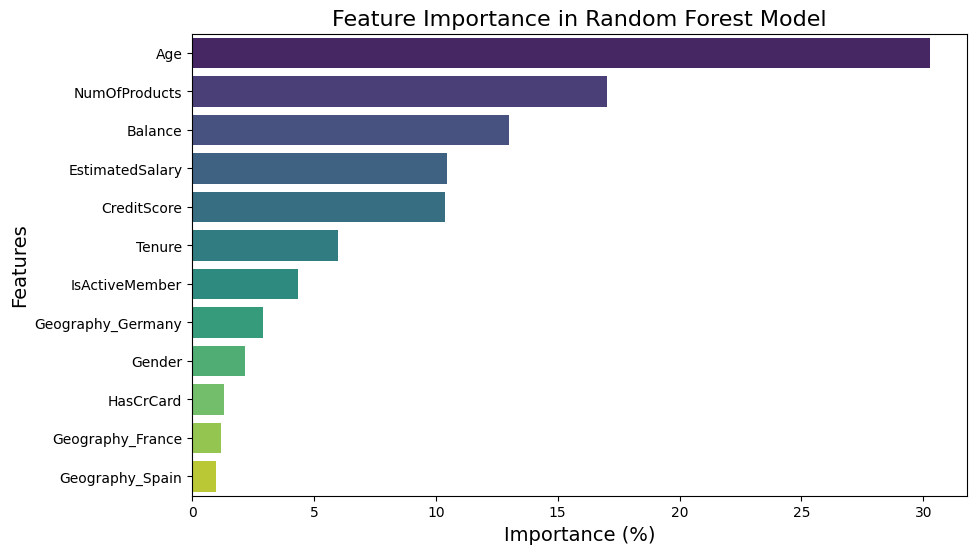

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting sorted feature names and their importance values
features = [feature for feature, _ in sorted_feature_importances]
importances_percent = [round(importance * 100, 2) for _, importance in sorted_feature_importances]

# Creating the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_percent, y=features, palette='viridis')

# Adding labels and title
plt.title("Feature Importance in Random Forest Model", fontsize=16)
plt.xlabel("Importance (%)", fontsize=14)
plt.ylabel("Features", fontsize=14)

plt.show()

##Conclusions
In the Random Forest model, the most influential features are:



*   Age: 30.28%

*   NumOfProducts: 17.02%
*   Balance: 12.99%


*   EstimatedSalary: 10.46%

*   CreditScore: 10.38%




Polynomial transformations are generally more appropriate for continuous variables. Therefore, NumOfProducts will be excluded from the selected feature set before generating polynomial features.

In [ ]:
#feature engineering

# Redefining columns for polynomial feature use in the Random Forest model

from sklearn.preprocessing import PolynomialFeatures

# Defining column categories
categorical_columns = ['Geography']
numerical_columns = ['Tenure', 'NumOfProducts']
boolean_columns = ['HasCrCard', 'IsActiveMember', 'Gender']
polynomial_columns = ['Age', 'Balance', 'EstimatedSalary', 'CreditScore']

# Pipeline for categorical columns (One-Hot Encoding)
cat_pipe = Pipeline(steps=[('ohe', OneHotEncoder())])

# Pipeline for numerical columns (Standardization)
num_pipe = Pipeline(steps=[('std', StandardScaler())])

# Pipeline for polynomial features (Standardization + Polynomial Transformation)
poly_pipe = Pipeline(steps=[
    ('std', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False))
])

# Defining the preprocessing steps for different feature types
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, categorical_columns),
        ('num', num_pipe, numerical_columns),
        ('bool', 'passthrough', boolean_columns),
        ('pol', poly_pipe, polynomial_columns),
    ],
    remainder='drop'
)

In [ ]:
# Creating a pipeline for the model
rf_poly_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [ ]:
#fitting the model to the data
rf_poly_pipe.fit(X=features_train_resampled, y=target_train_resampled)

# Saving model
joblib.dump(rf_poly_pipe, '../models/rf_poly_pipe.pkl')

# evaluation of prediction
target_test_pred = rf_poly_pipe.predict(X=features_test_cleaned)
print(classification_report(y_true=target_test, y_pred=target_test_pred))

conf_matrix = confusion_matrix(y_true=target_test, y_pred=target_test_pred)
print("Confusion Matrix:\n", conf_matrix)
roc_auc = roc_auc_score(target_test, rf_poly_pipe.predict_proba(features_test_cleaned)[:, 1])
print("\nroc_auc:", roc_auc)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       809
           1       0.64      0.50      0.56       191

    accuracy                           0.85      1000
   macro avg       0.76      0.72      0.74      1000
weighted avg       0.84      0.85      0.84      1000

Confusion Matrix:
 [[755  54]
 [ 95  96]]

roc_auc: 0.8408124567205328


##Conclusion

*   The model performs considerably worse when polynomial features are included compared to the version without them.
*   It may be beneficial to examine whether hyperparameter optimization can enhance the model’s performance.



In [ ]:
# Defining the search space for hyperparameter tuning

search_space_rf_poly = {
    'classifier__n_estimators': np.round(np.geomspace(10, 100, num=6)).astype(int),
    'classifier__max_depth': np.round(np.geomspace(3, 50, num=10)).astype(int),
    'classifier__min_samples_leaf': [5, 10, 20]
}

# Creating a pipeline for the Random Forest model with polynomial features
rf_poly_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Grid search with cross-validation and parallel computation
rf_poly_grid_search = GridSearchCV(
    estimator=rf_poly_pipe,
    param_grid=search_space_rf_poly,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

#fitting the model to the data
rf_poly_grid_search.fit(features_train_resampled, target_train_resampled)

# saving the GridSearchCV object
joblib.dump(rf_poly_grid_search, '../models/rf_poly_grid_search.pkl')

Fitting 5 folds for each of 180 candidates, totalling 900 fits


['../models/rf_poly_grid_search.pkl']

In [ ]:
# loading the GridSearchCV object
rf_poly_grid_search = joblib.load('../models/rf_poly_grid_search.pkl')

# Grid search results:
display(rf_poly_grid_search)

# Printing the best model and its score
print("Best Model:\n", rf_poly_grid_search.best_estimator_)
print("\nBest F1-Score:", rf_poly_grid_search.best_score_)
print("\nBest Parameters:\n", rf_poly_grid_search.best_estimator_.get_params())

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder())]),
                                                                         ['Geography']),
                                                                        ('num',
                                                                         Pipeline(steps=[('std',
                                                                                          StandardScaler())]),
                                                                         ['Tenure',
                                                                          'NumOfProducts']),
                                                                        ('bool',
                                                                         'passthrough',
                                                                         ['HasCrCard',
                                                                          'IsActiveMember',
                                                                          'Gender']),
                                                                        ('pol',
                                                                         Pipeline(steps=[('std',
                                                                                          StandardScaler()),
                                                                                         ('poly',
                                                                                          PolynomialFeatures(include_bias=False))]),
                                                                         ['Age',
                                                                          'Balance',
                                                                          'EstimatedSalary',
                                                                          'CreditScore'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': array([ 3,  4,  6,  8, 10, 14, 20, 27, 37, 50]),
                         'classifier__min_samples_leaf': [5, 10, 20],
                         'classifier__n_estimators': array([ 10,  16,  25,  40,  63, 100])},
             scoring='f1', verbose=1)

Best Model:
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder())]),
                                                  ['Geography']),
                                                 ('num',
                                                  Pipeline(steps=[('std',
                                                                   StandardScaler())]),
                                                  ['Tenure', 'NumOfProducts']),
                                                 ('bool', 'passthrough',
                                                  ['HasCrCard',
                                                   'IsActiveMember',
                                                   'Gender']),
                                                 ('pol',
                                             

##The main best parameters are:


*   max_depth=20

*   n_estimators=100
*   min_samples_leaf= 5


*   min_samples_split=2



In [ ]:
# Save the model
joblib.dump(rf_poly_grid_search.best_estimator_, '../models/rf_poly_after_grid_search.pkl')

# Load the model
model_rf_poly_after_grid_search = joblib.load('../models/rf_poly_after_grid_search.pkl')

In [ ]:
# Evaluating model

# Prediction on the test data
target_test_pred = model_rf_poly_after_grid_search.predict(features_test_cleaned)

# Classification report
print(classification_report(target_test, target_test_pred))

# Computing and displaying the confusion matrix
print("Confusion Matrix:\n", confusion_matrix(target_test, target_test_pred))

# Calculating and displaying the ROC AUC score
print("\nROC AUC Score:", roc_auc_score(target_test, model_rf_poly_after_grid_search.predict_proba(features_test_cleaned)[:, 1]))

              precision    recall  f1-score   support

           0       0.91      0.90      0.90       809
           1       0.59      0.63      0.61       191

    accuracy                           0.85      1000
   macro avg       0.75      0.76      0.76      1000
weighted avg       0.85      0.85      0.85      1000

Confusion Matrix:
 [[726  83]
 [ 71 120]]

ROC AUC Score: 0.8515004627262668


##Conclusion

*   Following hyperparameter tuning, improvements are observed in the F1-score as well as other evaluation metrics
*   Nevertheless, the F1-score remains slightly below the level achieved by the Random Forest model without polynomial features



In [ ]:
# Creating a list of transformed column names and the corresponding DataFrame

# Transforming training data using the preprocessor
transformed_features_train = preprocessor.fit_transform(features_train_resampled)

# Transforming test data using the same preprocessor
transformed_features_test = preprocessor.transform(features_test_cleaned)

# Extracting feature names after transformation:
# 1. Extracting OneHotEncoded column names from "Geography"
geography_columns = preprocessor.transformers_[0][1].named_steps['ohe'].get_feature_names_out(input_features=['Geography'])

# 2. Extracting polynomial feature names
polynomial_transformer = preprocessor.transformers_[3][1].named_steps['poly']
poly_columns = polynomial_transformer.get_feature_names_out(input_features=polynomial_columns)

# Combining all feature names in the correct order
all_transformed_columns = list(geography_columns) + numerical_columns + boolean_columns + list(poly_columns)

# Creating a DataFrame with transformed training data
transformed_train_df = pd.DataFrame(transformed_features_train, columns=all_transformed_columns)

# Creating a DataFrame with transformed test data
transformed_test_df = pd.DataFrame(transformed_features_test, columns=all_transformed_columns)

# Displaying the transformed test data
display(transformed_test_df)

,Geography_France,Geography_Germany,Geography_Spain,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Gender,Age,Balance,...,Age^2,Age Balance,Age EstimatedSalary,Age CreditScore,Balance^2,Balance EstimatedSalary,Balance CreditScore,EstimatedSalary^2,EstimatedSalary CreditScore,CreditScore^2
0,0.0,1.0,0.0,-0.679701,0.743676,0.0,0.0,0.0,-0.863233,0.253035,...,0.745172,-0.218428,0.883883,0.473122,0.064027,-0.259088,-0.138684,1.048416,0.561192,0.300393
1,1.0,0.0,0.0,-1.368720,0.743676,1.0,1.0,0.0,0.172992,-1.324627,...,0.029926,-0.229149,0.136828,-0.047174,1.754636,-1.047712,0.361217,0.625600,-0.215686,0.074362
2,0.0,0.0,1.0,-0.335191,0.743676,1.0,0.0,1.0,0.267194,-1.324627,...,0.071393,-0.353932,-0.195820,-0.132818,1.754636,0.970787,0.658450,0.537108,0.364301,0.247092
3,0.0,1.0,0.0,1.042847,0.743676,1.0,1.0,0.0,1.680228,0.619159,...,2.823167,1.040328,2.037465,-2.463283,0.383358,0.750799,-0.907712,1.470428,-1.777739,2.149276
4,0.0,0.0,1.0,0.698337,-0.761135,1.0,1.0,1.0,-1.334245,0.714493,...,1.780209,-0.953308,-0.321183,1.221188,0.510500,0.171995,-0.653950,0.057947,-0.220325,0.837710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,-0.679701,0.743676,1.0,0.0,0.0,1.680228,-1.324627,...,2.823167,-2.225675,-2.185296,-1.417891,1.754636,1.722803,1.117810,1.691547,1.097531,0.712114
996,1.0,0.0,0.0,1.042847,0.743676,1.0,0.0,0.0,-0.674829,-1.324627,...,0.455394,0.893896,0.728657,0.094543,1.754636,1.430285,0.185579,1.165892,0.151274,0.019628
997,1.0,0.0,0.0,-0.679701,-0.761135,1.0,0.0,1.0,-1.428447,0.601961,...,2.040461,-0.859869,0.980038,-0.586630,0.362357,-0.412997,0.247211,0.470714,-0.281760,0.168655
998,0.0,0.0,1.0,-0.679701,-0.761135,1.0,0.0,0.0,0.267194,0.125900,...,0.071393,0.033640,-0.144187,-0.538881,0.015851,-0.067940,-0.253918,0.291207,1.088347,4.067549


In [ ]:
# Extracting the RandomForestClassifier model from the pipeline
rf_poly_classifier = model_rf_poly_after_grid_search.named_steps['classifier']

# Retrieving feature importance scores from the model
importances = rf_poly_classifier.feature_importances_

# Combining feature names with their respective importance scores
feature_importances_with_names = list(zip(all_transformed_columns, importances))

# Sorting features by importance in descending order
sorted_feature_importances = sorted(feature_importances_with_names, key=lambda x: x[1], reverse=True)

# Displaying sorted features along with their importance scores as percentages
print("Feature Importances:")
for feature, importance in sorted_feature_importances:
    importance_percent = round(importance * 100, 2)
    print(f"{feature}: {importance_percent}%")

Feature Importances:
Age: 17.71%
NumOfProducts: 12.56%
Age Balance: 8.05%
Balance: 5.76%
Balance^2: 4.72%
Age EstimatedSalary: 4.25%
Balance EstimatedSalary: 4.08%
Age CreditScore: 4.06%
EstimatedSalary^2: 3.99%
EstimatedSalary CreditScore: 3.96%
Balance CreditScore: 3.92%
EstimatedSalary: 3.84%
Age^2: 3.82%
CreditScore: 3.78%
CreditScore^2: 3.7%
IsActiveMember: 3.39%
Tenure: 2.49%
Geography_Germany: 2.29%
Gender: 1.5%
Geography_France: 0.91%
Geography_Spain: 0.68%
HasCrCard: 0.57%


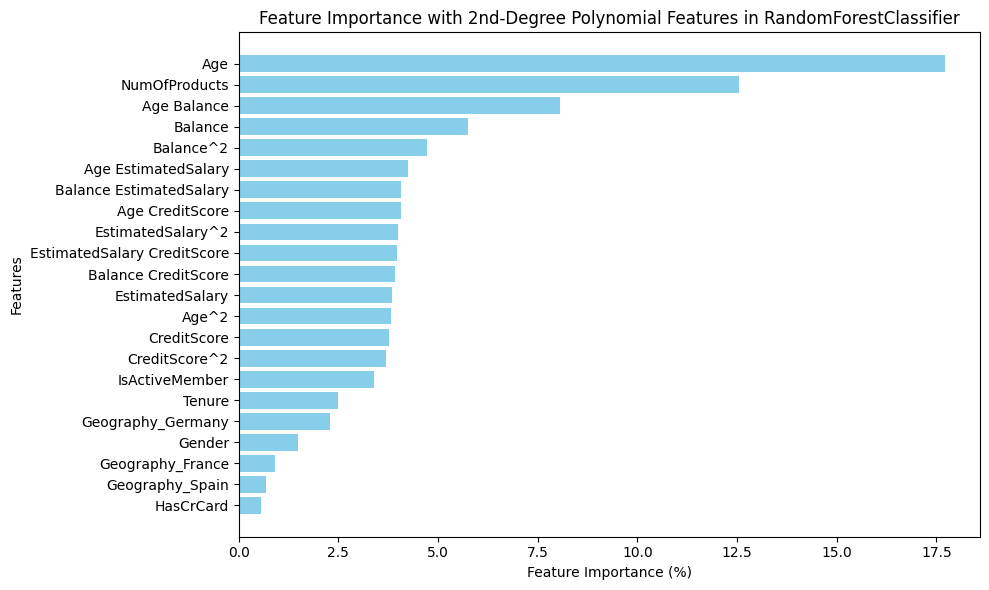

In [ ]:
# Extracting feature names and their importance scores from the sorted list
features, importances = zip(*sorted_feature_importances)

# Converting importance scores to percentages
importances_percent = [round(imp * 100, 2) for imp in importances]

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(features, importances_percent, color='skyblue')
plt.xlabel("Feature Importance (%)")
plt.ylabel("Features")
plt.title("Feature Importance with 2nd-Degree Polynomial Features in RandomForestClassifier")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##Conclusions

*   As a result of applying polynomial feature engineering, the total number of features increased from 12 to 22.
*   As in the previous model, Age and Balance remain the most important features.



In [ ]:
# Reducing number of features with importance below 2%

columns_to_keep = [
'Age',
'NumOfProducts',
'Age Balance',
'Balance',
'Balance EstimatedSalary',
'Age EstimatedSalary',
'Balance^2',
'Age CreditScore',
'EstimatedSalary^2',
'Balance CreditScore',
'EstimatedSalary CreditScore',
'EstimatedSalary',
'CreditScore^2',
'CreditScore',
'Age^2',
'Tenure',
'IsActiveMember',
'Geography_Germany',
#'Gender',
#'Geography_France',
#'HasCrCard',
#'Geography_Spain',
]

transformed_reduced_poly_features_test = transformed_test_df[columns_to_keep]
transformed_reduced_poly_features_train = transformed_train_df[columns_to_keep]

In [ ]:
display(transformed_reduced_poly_features_train)

,Age,NumOfProducts,Age Balance,Balance,Balance EstimatedSalary,Age EstimatedSalary,Balance^2,Age CreditScore,EstimatedSalary^2,Balance CreditScore,EstimatedSalary CreditScore,EstimatedSalary,CreditScore^2,CreditScore,Age^2,Tenure,IsActiveMember,Geography_Germany
0,-0.015413,-0.761135,-0.002619,0.169899,-0.213351,0.019355,0.028866,0.007033,1.576920,-0.077522,0.572982,-1.255755,0.208196,-0.456285,0.000238,0.009318,1.0,0.0
1,1.115015,-0.761135,0.600897,0.538914,-0.460176,-0.952105,0.290428,1.163015,0.729136,0.562114,-0.890654,-0.853894,1.087951,1.043049,1.243257,1.042847,1.0,0.0
2,-0.298020,0.743676,0.394765,-1.324627,0.486781,0.109518,1.754636,0.245410,0.135045,1.090789,0.302613,-0.367485,0.678101,-0.823469,0.088816,1.042847,0.0,0.0
3,1.209217,-0.761135,1.774191,1.467224,1.686099,1.389603,2.152745,0.743266,1.320606,0.901855,0.706362,1.149176,0.377816,0.614668,1.462205,0.353828,1.0,0.0
4,1.209217,-0.761135,-1.601761,-1.324627,0.555674,-0.507260,1.754636,-2.944441,0.175976,3.225463,1.021469,-0.419495,5.929216,-2.434998,1.462205,1.387357,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14303,0.644003,-0.761135,0.273673,0.424956,0.021496,0.032576,0.180588,-0.103361,0.002559,-0.068205,-0.008118,0.050583,0.025760,-0.160498,0.414740,-1.024210,1.0,1.0
14304,0.078789,-0.761135,0.031522,0.400078,-0.071079,-0.013998,0.160063,0.024321,0.031564,0.123497,-0.054841,-0.177663,0.095284,0.308681,0.006208,0.698337,1.0,1.0
14305,-0.203817,-0.761135,0.269982,-1.324627,-1.379421,-0.212249,1.754636,0.508768,1.084444,3.306527,-2.599454,1.041366,6.230992,-2.496196,0.041542,1.731866,0.0,0.0
14306,-0.392222,-0.761135,-0.438706,1.118514,-1.555936,0.545610,1.251074,-0.213083,1.935087,0.607656,-0.755730,-1.391074,0.295143,0.543271,0.153838,-1.368720,0.0,0.0


In [ ]:
# Defining the search space for hyperparameter tuning
search_space_rf = {
    'n_estimators': np.round(np.geomspace(10, 100, num=6)).astype(int),
    'max_depth': np.round(np.geomspace(3, 50, num=10)).astype(int),
    'min_samples_leaf': [5, 10, 20]
}

# Grid search with cross-validation and parallel computation
rf_reduced_poly_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=search_space_rf,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fitting the model using resampled training data
rf_reduced_poly_grid_search.fit(transformed_reduced_poly_features_train, target_train_resampled)

# saving the GridSearchCV object
joblib.dump(rf_reduced_poly_grid_search, '../models/rf_reduced_poly_grid_search.pkl')

Fitting 5 folds for each of 180 candidates, totalling 900 fits


['../models/rf_reduced_poly_grid_search.pkl']

In [ ]:
# loading the GridSearchCV object
rf_reduced_poly_grid_search = joblib.load('../models/rf_reduced_poly_grid_search.pkl')

#display(rf_reduced_poly_grid_search) # rf classifier on transformed_reduced_poly_features_train

# Printing the best model and its score
print("Best Model:\n", rf_reduced_poly_grid_search.best_estimator_)
print("\nBest F1 Score:", rf_reduced_poly_grid_search.best_score_)
print("\nBest Parameters:\n", rf_reduced_poly_grid_search.best_estimator_.get_params())

Best Model:
 RandomForestClassifier(max_depth=np.int64(37), min_samples_leaf=5,
                       n_estimators=np.int64(63), random_state=42)

Best F1 Score: 0.9190168321406288

Best Parameters:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': np.int64(37), 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': np.int64(63), 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


##The main best parameters are:

*   max_depth=37

*   n_estimators=63
*   min_samples_leaf= 5


*   min_samples_split=2



In [ ]:
# Save the model
joblib.dump(rf_reduced_poly_grid_search.best_estimator_, '../models/rf_reduced_poly_after_grid_search.pkl')

# Load the model
model_rf_reduced_poly_grid_search = joblib.load('../models/rf_reduced_poly_after_grid_search.pkl')

In [ ]:
# Prediction on the test data
target_test_pred = model_rf_reduced_poly_grid_search.predict(transformed_reduced_poly_features_test)

# Classification report
print(classification_report(target_test, target_test_pred))

# Computing and displaying the confusion matrix
print("Confusion Matrix:\n", confusion_matrix(target_test, target_test_pred))

# Calculating and displaying the ROC AUC score
print("\nROC AUC Score:", roc_auc_score(target_test, model_rf_reduced_poly_grid_search.predict_proba(transformed_reduced_poly_features_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89       809
           1       0.55      0.56      0.56       191

    accuracy                           0.83      1000
   macro avg       0.73      0.73      0.73      1000
weighted avg       0.83      0.83      0.83      1000

Confusion Matrix:
 [[723  86]
 [ 84 107]]

ROC AUC Score: 0.8425112769303452


The best model with metrics: ROC AUC = 0.86 and f1-score = 62% was Random Forest after hyperparameter tunning, without polynomial features.

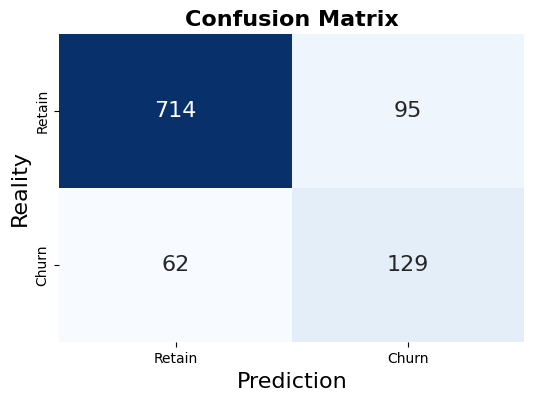

In [ ]:
# Confusion matrix of the best model: Random Forest without Polynomials, after hyperparameter tuning

plt.figure(figsize=(6, 4))  # Figure size
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retain','Churn'], yticklabels=['Retain','Churn'],
            annot_kws={'size': 16})

# Title and axis labels
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Prediction', fontsize=16)
plt.ylabel('Reality', fontsize=16)
plt.show()

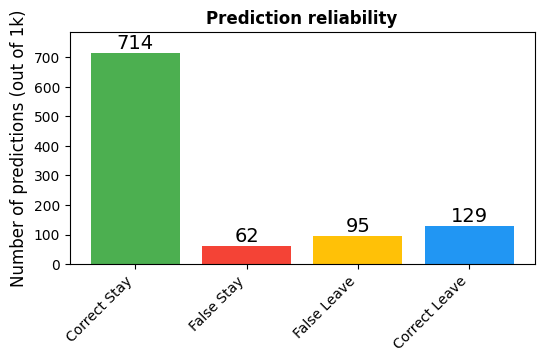

In [ ]:
# Presenting results of confusion matrix in colmn chart.

fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Correct Stay', 'False Stay', 'False Leave', 'Correct Leave']
sizes = [conf_matrix_rf[0, 0], conf_matrix_rf[1, 0], conf_matrix_rf[0, 1], conf_matrix_rf[1, 1]]
colors = ['#4CAF50', '#F44336', '#FFC107', '#2196F3']

ax.bar(labels, sizes, color=colors)

plt.title('Prediction reliability', fontsize=12, fontweight='bold')
#plt.xlabel('Type of prediction', fontsize=12)
plt.ylabel('Number of predictions (out of 1k)', fontsize=12)

# Adding values on the columns
for i, v in enumerate(sizes):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=14)

plt.xticks(rotation=45, ha='right')

# Adjusting the Y-axis to create more space at the top
ax.set_ylim(0, max(sizes) * 1.1)


# Adjust the bottom margin to prevent cutting off xticks
plt.subplots_adjust(bottom=0.3)

plt.show()

In [ ]:
print(class_report_rf)

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       809
           1       0.58      0.68      0.62       191

    accuracy                           0.84      1000
   macro avg       0.75      0.78      0.76      1000
weighted avg       0.85      0.84      0.85      1000



##Interpretation and final comments:
Without incorporating polynomial features, the Random Forest algorithm emerged as the optimal model, achieving an F1-score of 62% and a ROC AUC of 0.86. Its specific hyperparameter configuration included max_depth=20, n_estimators=100, min_samples_leaf=5, and min_samples_split=2.

In terms of performance, the model attained an overall accuracy of 84% across both customer classes (retained and churned). Out of all predicted churn cases, 58% were accurate (precision), while the model successfully captured 68% of the actual churners (recall). The hyperparameter tuning prioritized the F1-score to strike a robust balance between precision and recall. Nevertheless, alternative strategies could be explored to maximize either metric, depending on specific banking objectives.

Due to the sensitive nature of banking data, synthetic rather than real-world data was utilized for this analysis and forecasting. Consequently, these findings should not be generalized to actual customer behavior. Given the weak correlations among features in this specific dataset, the predictive power of the models is inherently constrained. However, the primary objective of this project was to demonstrate viable methodology within the broader context of customer churn analysis.